# Player Efficiency & Usage Scatterplot
# Explores the relationship between how much a player is used vs. how efficiently they score.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np

df = pd.read_csv('../data/fact_player_games.csv')
df.head()

,SEASON_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
0,42024,1628396,Tony Bradley,1610612754,IND,Indiana Pacers,42400407,2025-06-22,IND @ OKC,L,...,1.0,0,1,1,0,0,0,1,2,-2
1,42024,1631097,Bennedict Mathurin,1610612754,IND,Indiana Pacers,42400407,2025-06-22,IND @ OKC,L,...,1.0,7,6,13,3,2,0,3,3,-14
2,42024,1630174,Aaron Nesmith,1610612754,IND,Indiana Pacers,42400407,2025-06-22,IND @ OKC,L,...,NaN,1,5,6,1,2,2,1,6,6
3,42024,1630598,Aaron Wiggins,1610612760,OKC,Oklahoma City Thunder,42400407,2025-06-22,OKC vs. IND,W,...,NaN,0,1,1,0,0,0,0,1,11
4,42024,1627936,Alex Caruso,1610612760,OKC,Oklahoma City Thunder,42400407,2025-06-22,OKC vs. IND,W,...,NaN,2,1,3,0,3,1,0,3,8


## Step 1: Filter & Aggregate
Minimum qualifiers: **avg MIN >= 10** across all games, **at least 15 games** played.

In [7]:
# Drop players who average fewer than 10 minutes across all their games
avg_min = df.groupby('PLAYER_ID')['MIN'].mean()
qualified_ids = avg_min[avg_min >= 10].index
qualified = df[df['PLAYER_ID'].isin(qualified_ids)].copy()

# Per-player game counts — keep players with at least 15 games
game_counts = qualified.groupby('PLAYER_ID')['GAME_ID'].count()
qualified_ids = game_counts[game_counts >= 15].index
qualified = qualified[qualified['PLAYER_ID'].isin(qualified_ids)]

# Aggregate to per-player per-game averages
agg = qualified.groupby(['PLAYER_ID', 'PLAYER_NAME']).agg(
    games=('GAME_ID', 'count'),
    min_pg=('MIN', 'mean'),
    pts_pg=('PTS', 'mean'),
    fga_pg=('FGA', 'mean'),
    fta_pg=('FTA', 'mean'),
    tov_pg=('TOV', 'mean'),
).reset_index()

print(f"{len(agg)} players after filters")

428 players after filters


## Step 2: Compute Metrics

- **Usage proxy** = (FGA + 0.44 × FTA + TOV) / MIN  — approximates possessions used per minute
- **True Shooting %** = PTS / (2 × (FGA + 0.44 × FTA))  — standard scoring efficiency metric

In [8]:
agg['ts_attempts'] = agg['fga_pg'] + 0.44 * agg['fta_pg']

# Drop players with near-zero attempts (edge cases like DNP-heavy games slipping through)
agg = agg[agg['ts_attempts'] > 1].copy()

agg['usage'] = (agg['fga_pg'] + 0.44 * agg['fta_pg'] + agg['tov_pg']) / agg['min_pg']
agg['ts_pct'] = agg['pts_pg'] / (2 * agg['ts_attempts'])

agg[['PLAYER_NAME', 'games', 'min_pg', 'pts_pg', 'usage', 'ts_pct']].sort_values('pts_pg', ascending=False).head(20)

,PLAYER_NAME,games,min_pg,pts_pg,usage,ts_pct
142,Shai Gilgeous-Alexander,105,33.857143,30.942857,0.805221,0.622519
47,Giannis Antetokounmpo,75,34.120000,30.280000,0.802704,0.624203
164,Luka Dončić,55,35.890909,28.345455,0.771044,0.589173
67,Nikola Jokić,88,36.500000,28.034091,0.685193,0.647901
210,Anthony Edwards,97,36.432990,27.010309,0.712835,0.588722
111,Jayson Tatum,84,35.976190,26.404762,0.709133,0.582458
139,Jalen Brunson,87,35.241379,26.402299,0.695564,0.602381
300,Paolo Banchero,54,34.296296,25.592593,0.766998,0.547769
3,Kevin Durant,67,35.208955,25.507463,0.646901,0.641979
283,Cade Cunningham,80,34.575000,25.425000,0.778872,0.562699


## Step 3: Scatterplot — Usage vs. True Shooting %

Label the top 20 scorers. Color by points per game.

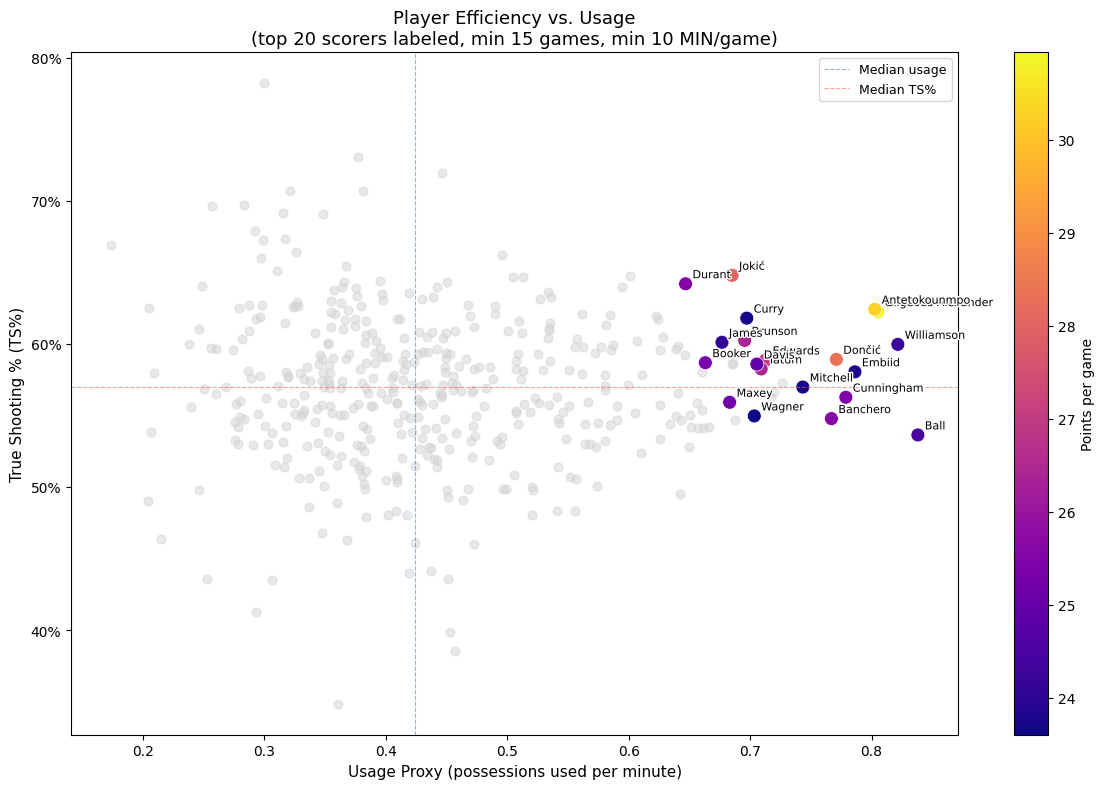

In [9]:
top_scorers = agg.nlargest(20, 'pts_pg')

fig, ax = plt.subplots(figsize=(12, 8))

# All players as grey background
sc_all = ax.scatter(
    agg['usage'], agg['ts_pct'],
    c='lightgrey', alpha=0.5, s=40, zorder=1
)

# Top 20 scorers colored by pts_pg
sc_top = ax.scatter(
    top_scorers['usage'], top_scorers['ts_pct'],
    c=top_scorers['pts_pg'], cmap='plasma', s=100,
    edgecolors='white', linewidths=0.5, zorder=2
)

# Labels for top 20
for _, row in top_scorers.iterrows():
    # Use last name only to reduce clutter
    label = row['PLAYER_NAME'].split()[-1]
    ax.annotate(
        label,
        xy=(row['usage'], row['ts_pct']),
        xytext=(5, 4), textcoords='offset points',
        fontsize=8,
        path_effects=[pe.withStroke(linewidth=2, foreground='white')]
    )

# Reference lines at medians
ax.axvline(agg['usage'].median(), color='steelblue', linestyle='--', linewidth=0.8, alpha=0.6, label='Median usage')
ax.axhline(agg['ts_pct'].median(), color='tomato', linestyle='--', linewidth=0.8, alpha=0.6, label='Median TS%')

plt.colorbar(sc_top, ax=ax, label='Points per game')
ax.set_xlabel('Usage Proxy (possessions used per minute)', fontsize=11)
ax.set_ylabel('True Shooting % (TS%)', fontsize=11)
ax.set_title('Player Efficiency vs. Usage\n(top 20 scorers labeled, min 15 games, min 10 MIN/game)', fontsize=13)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()